In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('survey_results_public.csv', low_memory=False)
df1 = pd.read_csv('survey_results_schema.csv')

In [3]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [4]:
columns_list = df.columns.tolist()
columns_list

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

In [5]:
df1.info()
df1.head()

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   qid       139 non-null    str    
 1   qname     139 non-null    str    
 2   question  139 non-null    str    
 3   type      139 non-null    str    
 4   sub       49 non-null     str    
 5   sq_id     49 non-null     float64
dtypes: float64(1), str(5)
memory usage: 6.6 KB


,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0


**Завдання 1. Підрахунок загальної кількості респондентів**

In [6]:
respondents_count = df['ResponseId'].nunique()
print(f"Загальна кількість респондентів :{respondents_count}")

Загальна кількість респондентів :49191


**Завдання 2. Аналіз повноти відповідей респондентів**

In [7]:
df_q = df.copy()
df1_q = df1.copy()
qname_set = set(df1_q['qname'].astype(str).str.strip())
columns_set = set(df_q.columns.str.strip())
questions = qname_set.intersection(columns_set)
print(f"Кількість питань:{len(questions)}")
list_of_questions = list(questions)
respondents_all_answered = df[list_of_questions].dropna()
result = respondents_all_answered.shape[0] 
print(f"Респондентів що відповіли на всі питання: {result}")

Кількість питань:126
Респондентів що відповіли на всі питання: 0


*В принципі вірно тяжко відповісти більше як на 100 питань*

**Завдання 3. Статистичний аналіз досвіду респондентів**

In [8]:
missing = df['WorkExp'].isna().sum()
print(f"Кількість пропущених значень: {missing}")

# Варіант А: Аналіз тільки наявних відповідей 
print(f"\nСтатистика по наявних даних:")
print(f"Mean:   {round(df['WorkExp'].mean(), 2)}")
print(f"Median: {df['WorkExp'].median()}")
print(f"Mode: {df['WorkExp'].mode()[0]}")
# Варіант Б: Враховую пропуски як 0 
work_exp_zero = df['WorkExp'].fillna(0)
print(f"\nСтатистика з урахуванням пропусків (як 0):")
print(f"Mean:   {round(work_exp_zero.mean(), 2)}")
print(f"Median: {work_exp_zero.median()}")
print(f"Mode: {work_exp_zero.mode()[0]}")

Кількість пропущених значень: 6298

Статистика по наявних даних:
Mean:   13.37
Median: 10.0
Mode: 10.0

Статистика з урахуванням пропусків (як 0):
Mean:   11.66
Median: 9.0
Mode: 0.0


*Наочно можна побачити вплив заповнення порожніх значень цифрою 0*

**Завдання 4. Аналіз віддаленої роботи**

In [9]:
#print(df['RemoteWork'].unique())
remote_employment = df[df['RemoteWork'] == 'Remote']
print(f"Респонденти які працюють віддалено:{remote_employment.shape[0]}")

Респонденти які працюють віддалено:10931


**Завдання 5. Визначення популярності Python**

In [10]:
df['worked_with_python'] = df['LanguageHaveWorkedWith'].str.contains('Python',case=False, na=False)
#print(df['worked_with_python'].sum())
#print(df['worked_with_python'].count())
#percentage = df['worked_with_python'].mean() * 100
print(f"Відсоток респондентів {round((df['worked_with_python'].sum()/df['worked_with_python'].count())*100,1)}%")

Відсоток респондентів 37.5%


**Завдання 6. Аналіз шляхів навчання програмуванню**

In [11]:
online_courses_only = df['LearnCode'].str.contains('Online Courses', case=False, na=False).sum()
print(f"Кількість респондентів, які навчалися саме на онлайн-курсах: {online_courses_only}")

Кількість респондентів, які навчалися саме на онлайн-курсах: 10973


**Завдання 7. Географічний аналіз компенсації Python-розробників**

In [12]:
df_country_python = df.copy()
df_country_python = df_country_python[df_country_python['worked_with_python'] == True]
df_country_python = df_country_python.dropna(subset = ['ConvertedCompYearly'])
py_progres_by_country = df_country_python.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median']).reset_index()
print(py_progres_by_country.sort_values(by='median', ascending=False).head(10))

                      Country           mean    median
102                      Oman  390135.000000  390135.0
3                     Andorra  226103.500000  226103.5
145  United States of America  173298.590211  150000.0
65                     Israel  135828.365385  142594.0
132               Switzerland  156456.600000  142592.0
99                    Nomadic  120131.571429  139218.0
63                    Ireland  120523.918919  116015.0
78                 Luxembourg  116014.714286  109054.0
73                 Kyrgyzstan  106008.500000  106008.5
15                     Belize  102121.000000  102121.0


**Завдання 8. Аналіз освіти найбільш оплачуваних спеціалістів**

In [13]:
df_salary_education_level = df.copy()
df_salary_education_level = df_salary_education_level[['ResponseId', 'EdLevel', 'ConvertedCompYearly']]
df_salary_education_level = df_salary_education_level.dropna(subset = ['ConvertedCompYearly', 'EdLevel'])
top_5 = df_salary_education_level.sort_values(by='ConvertedCompYearly', ascending=False).reset_index(drop = True).head(5)
top_5

,ResponseId,EdLevel,ConvertedCompYearly
0,34268,"Associate degree (A.A., A.S., etc.)",50000000.0
1,28701,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",33552715.0
2,43144,"Associate degree (A.A., A.S., etc.)",18387548.0
3,35354,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",15430267.0
4,45972,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",13921760.0


**Завдання 9. Аналіз популярності Python по віковим категоріям**

In [14]:
df_popular = df.copy()
df_popular['worked_with_python'] = df_popular['LanguageHaveWorkedWith'].str.contains('Python',case=False, na=False)
df_popular = df_popular.dropna(subset = ['LanguageHaveWorkedWith'])
df_popular = df_popular[['Age', 'LanguageHaveWorkedWith', 'worked_with_python']]
df_popular = df_popular.groupby('Age').agg({'LanguageHaveWorkedWith':'count', 'worked_with_python':'sum'})
df_popular['percent'] = round((df_popular['worked_with_python']/df_popular['LanguageHaveWorkedWith'])*100,1)
df_popular = df_popular[['percent']].sort_values(by = 'percent', ascending=False).reset_index() 
df_popular

,Age,percent
0,18-24 years old,71.9
1,Prefer not to say,67.0
2,25-34 years old,59.5
3,35-44 years old,54.2
4,45-54 years old,54.1
5,55-64 years old,49.2
6,65 years or older,44.0


*Я надав два розрізи даних: перший показує частку Python серед активних розробників, а другий — серед усіх респондентів вікової групи. Це дозволяє уникнути викривлення результатів (Selection Bias) і дає повну картину ринку*.

In [15]:
df_popular_1 = df.copy()

df_popular_1['worked_with_python'] = df_popular_1['LanguageHaveWorkedWith'].str.contains('Python', case=False, na=False)

df_popular_result = df_popular_1.groupby('Age').agg(
    total_respondents=('Age', 'count'),
    python_users=('worked_with_python', 'sum')
)

df_popular_result['percent'] = round((df_popular_result['python_users'] / df_popular_result['total_respondents']) * 100, 1)

df_popular_final = df_popular_result[['percent']].sort_values(by='percent', ascending=False).reset_index()

df_popular_final

,Age,percent
0,18-24 years old,40.0
1,45-54 years old,38.6
2,55-64 years old,37.2
3,25-34 years old,36.9
4,35-44 years old,36.7
5,65 years or older,31.6
6,Prefer not to say,31.2


*Молодь частіше вибирає лекшу мову програмування високого рівня. З мого досвіду скажу, що користуватися jupyter notebook приємніше ніж компілятором*

**Завдання 10. Аналіз індустрій серед високооплачуваних віддалених працівників**

In [16]:
df_top_remove = df.copy()
df_top_remove = df_top_remove[df_top_remove['RemoteWork'] == 'Remote']
df_top_remove = df_top_remove.dropna(subset = ['ConvertedCompYearly'])
df_top_remove = df_top_remove[df_top_remove['ConvertedCompYearly'] > df_top_remove['ConvertedCompYearly'].quantile(0.75)]
top_industries = df_top_remove['Industry'].value_counts()
print(top_industries)

Industry
Software Development                          829
Fintech                                       137
Healthcare                                    120
Other:                                        117
Internet, Telecomm or Information Services     94
Banking/Financial Services                     58
Media & Advertising Services                   54
Retail and Consumer Services                   48
Government                                     47
Transportation, or Supply Chain                43
Computer Systems Design and Services           43
Insurance                                      28
Energy                                         27
Manufacturing                                  25
Higher Education                               16
Name: count, dtype: int64


*З великим відривом лідирує віддалене створення програмного забезпечення, що і логічно, наше навчання як частина цього прикладу*

In [17]:
df_clean = df.copy()
df_clean = df.dropna(subset=['LanguageHaveWorkedWith', 'Industry', 'ConvertedCompYearly'])

low = df_clean['ConvertedCompYearly'].quantile(0.25)
high = df_clean['ConvertedCompYearly'].quantile(0.75)

df_filtered = df_clean[
    (df_clean['ConvertedCompYearly'] >= low) & 
    (df_clean['ConvertedCompYearly'] <= high)
]

df_filtered['LanguageList'] = df_filtered['LanguageHaveWorkedWith'].str.split(';')

df_exploded = df_filtered.explode('LanguageList')

pivot_salary_final = df_exploded.pivot_table(
    index='LanguageList', 
    columns='Industry', 
    values='ConvertedCompYearly', 
    aggfunc='median'
)
pivot_salary_final = pivot_salary_final.dropna(thresh=5)
pivot_salary_final
global_median = pivot_salary_final.median().median()

# 2. Створюємо функцію для підсвітки
def color_profitability(val):
    if val > global_median * 1.2: # На 20% вище медіани - "Зона росту"
        return 'background-color: #77dd77' 
    elif val < global_median * 0.8: # На 20% нижче медіани - "Зона ризику"
        return 'background-color: #ff6961' 
    else:
        return 'background-color: #fdfd96' # Жовтий - "Середняк"
        

styled_table = pivot_salary_final.style.background_gradient(cmap='RdYlGn', axis=None) \
    .highlight_null(color='white') \
    .format("{:.0f}")

styled_table

Industry,Banking/Financial Services,Computer Systems Design and Services,Energy,Fintech,Government,Healthcare,Higher Education,Insurance,"Internet, Telecomm or Information Services",Manufacturing,Media & Advertising Services,Other:,Retail and Consumer Services,Software Development,"Transportation, or Supply Chain"
LanguageList,,,,,,,,,,,,,,,
Ada,61890,100000,67868,82484,62625,nan,77904,71060,104413,58007,104000,90111,nan,78382,58978
Assembly,80000,77150,78000,89775,79018,77730,69609,77500,86278,69609,45246,74249,89274,80732,69609
Bash/Shell (all shells),82018,81210,87011,84129,78959,81210,78000,86006,81210,81210,75607,80000,81761,77730,81210
C,80000,81210,80228,81685,78616,74392,72815,71884,79035,81826,61164,78595,76605,79316,75000
C#,86953,75144,86968,85088,80000,78308,80000,84691,72802,80925,75144,80000,76570,74878,81210
C++,72815,75086,83630,84574,80732,76051,68536,80050,82066,83046,65528,81685,79640,75410,82424
COBOL,54253,80050,nan,83531,93500,52207,75147,68449,nan,62221,nan,82977,100000,78310,63296
Dart,81210,87011,86319,73553,62068,69804,70769,76570,86403,84512,77832,66824,76570,69643,78000
Delphi,71929,100000,73733,94264,81210,75410,114545,56990,82926,80254,57274,83531,81210,75410,72196


<Axes: xlabel='Industry', ylabel='LanguageList'>

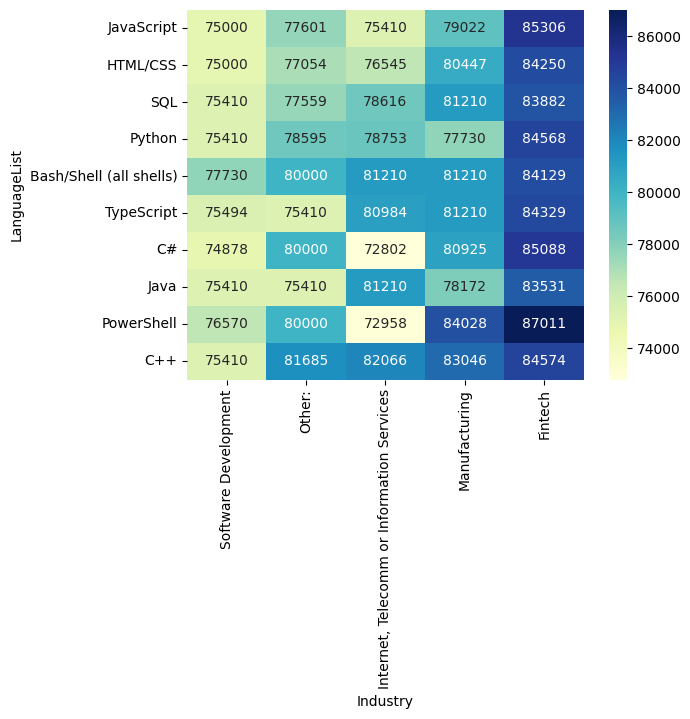

In [18]:
top_languages = df_exploded['LanguageList'].value_counts().nlargest(10).index

top_industries = df_exploded['Industry'].value_counts().nlargest(5).index

pivot_top = pivot_salary_final.loc[top_languages, top_industries]

sns.heatmap(pivot_top, annot=True, fmt=".0f", cmap="YlGnBu")